In [1]:
import matplotlib.pyplot as plt 

In [2]:
from histonaut.slide.reader import get_slide_reader

SLIDE_PATH = "/cluster/CBIO/home/mblons/py-packages/HISTONAUT/data/HE/SR386_40X_HE_T001_01.ome.tiff"
reader = get_slide_reader(SLIDE_PATH)
try:
    slide = reader(SLIDE_PATH)
except Exception as e:
    print(f"Error while trying to open wsi: {e}")
print(f"mpp at level 0: {slide.mpp}")
print(f"magnification: {slide.magnification}")
print(f"level count: {slide.level_count}")
print(f"level dimensions: {slide.level_dimensions}")
print(f"level downsamples {slide.level_downsamples}")


mpp at level 0: 0.5
magnification: 20
level count: 8
level dimensions: [(63758, 40190), (31879, 20095), (15939, 10047), (7969, 5023), (3984, 2511), (1992, 1255), (996, 627), (498, 313)]
level downsamples [1.0, 2.0, 4.000199064397332, 8.001194505275732, 16.00557546794106, 32.02390438247012, 64.09888357256779, 128.40255591054313]


slide shape = (7969, 5023) at level = 3


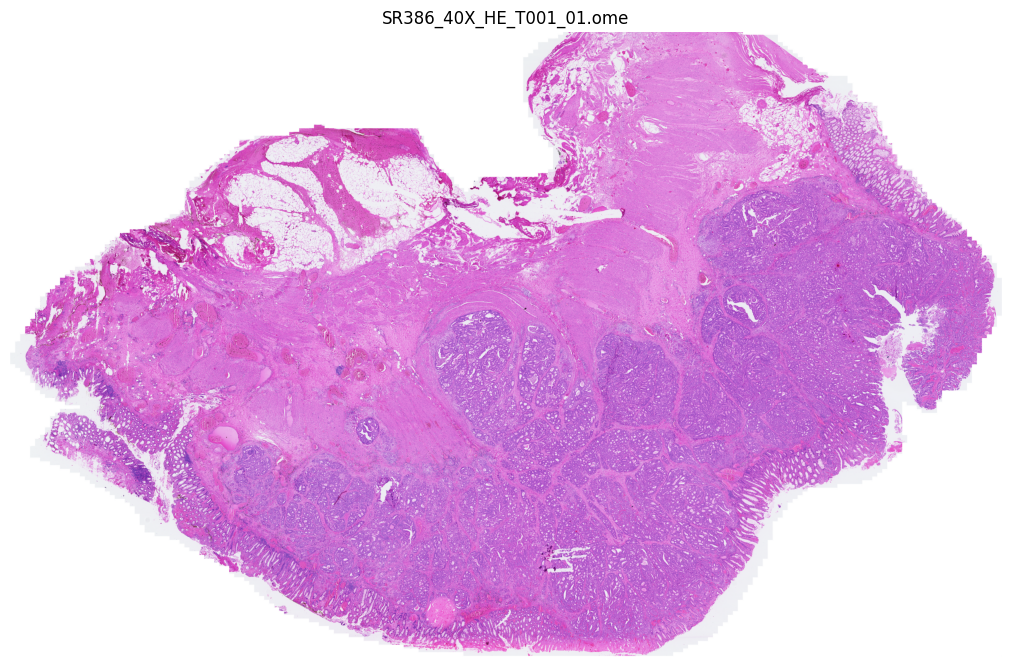

In [3]:
# Display slide with read_whole()
res_to_view = 3
img_slide = slide.read_whole(level=res_to_view)
print(f"slide shape = {slide.level_dimensions[res_to_view]} at level = {res_to_view}")
fig, ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")
ax.imshow(img_slide, aspect="equal")
ax.set_title(f"{slide.name}")
ax.set_axis_off()
plt.show()

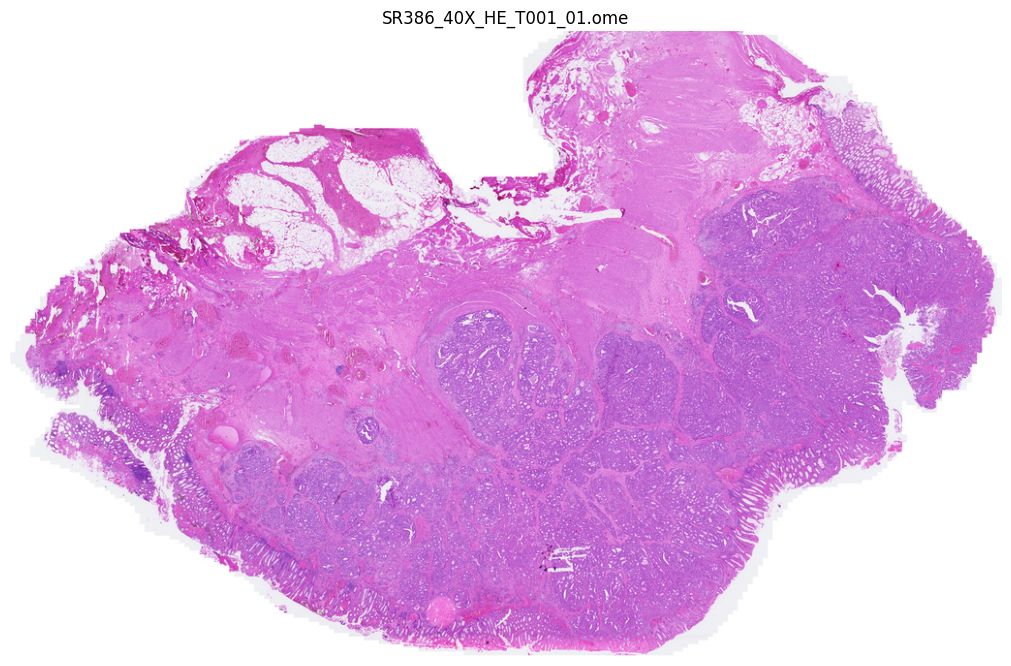

In [4]:
# Display a thumbnail
thumbnail = slide.get_thumbnail(size=(1024, 1024))
fig, ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")
ax.set_axis_off()
ax.imshow(thumbnail, aspect="equal")
ax.set_title(f"{slide.name}")
plt.show()

In [5]:
from histonaut.patcher.cut import SlidePatcher

PATCH_SIZE = 224
SOURCE_MAG = slide.magnification
TARGET_MAG = 20
OVERLAP = 0
MASK_DOWNSAMPLE = 64
MASK_TOLERANCE = 0.5
OUTPUT_DIR = f"./1_tutorial/tile_feat_{TARGET_MAG}x_{PATCH_SIZE}px_{OVERLAP}px_overlap"

patcher = SlidePatcher(
    slide,
    mag_0=SOURCE_MAG,
    mag_target=TARGET_MAG,
    patch_size=PATCH_SIZE,
    overlap=OVERLAP,
    mask_downsample=MASK_DOWNSAMPLE,
    mask_tolerance=MASK_TOLERANCE,
    mask_strategy="luminosity",
    xywh_only=False,
    dst=OUTPUT_DIR,
)
print(f"target mag: {patcher.mag_target}")
print(f"level: {patcher.level}")
print(f"mask downsampling: {patcher.mask_downsample}")
print(f"mask level: {patcher.level_mask}")

target mag: 20
level: 0
mask downsampling: 64
mask level: 5


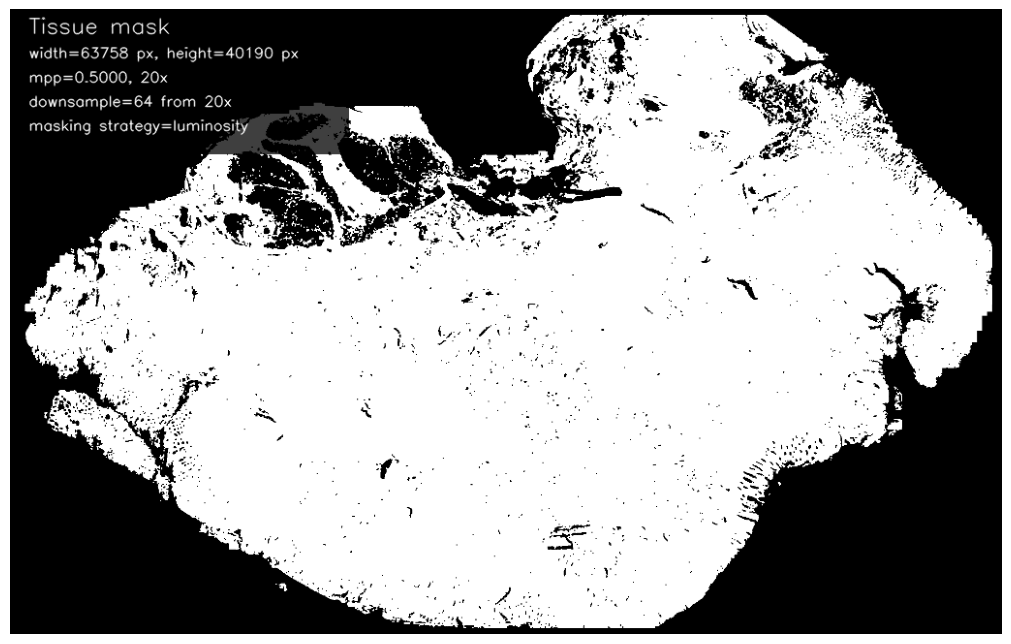

In [6]:
# visu mask
patcher.visualize_tissue_seg(size=(1024, 1024), show=True)

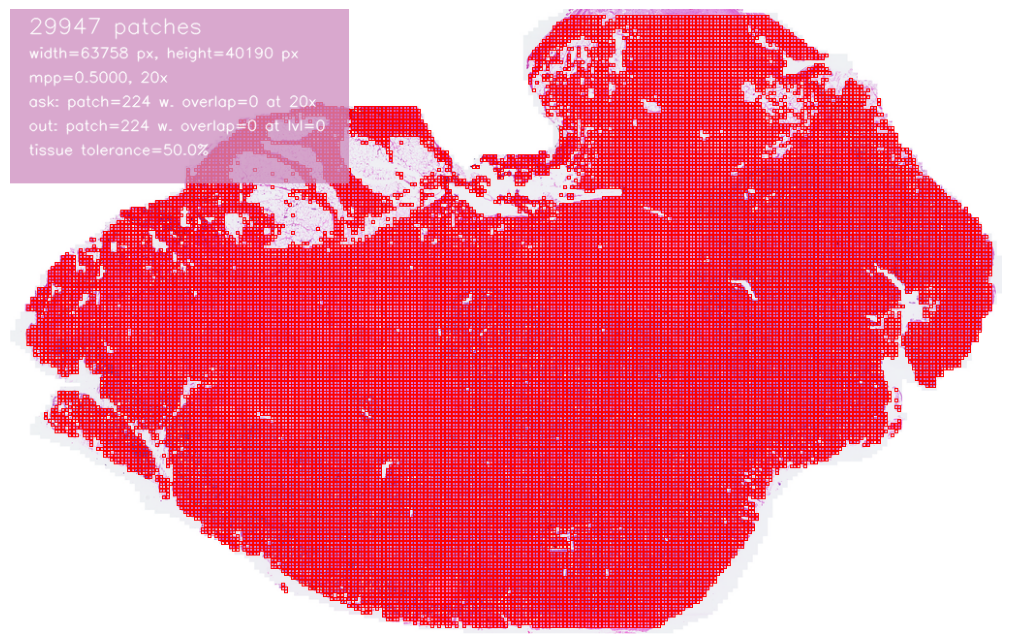

In [ ]:
# visu cut
patcher.visualize_cut(size=(1024, 1024), show=True)

In [9]:
from histonaut.patcher.sampler import PatchSampler
import numpy as np

n_tiles = 9
idx_samples = np.random.choice(patcher.nb_valid_patches, n_tiles, replace=False)
patch_sampler = PatchSampler(patcher=patcher)
tiles = []
coords = []
for i in idx_samples:
    tile, coord = patch_sampler[i]
    tiles.append(tile)
    coords.append(coord)

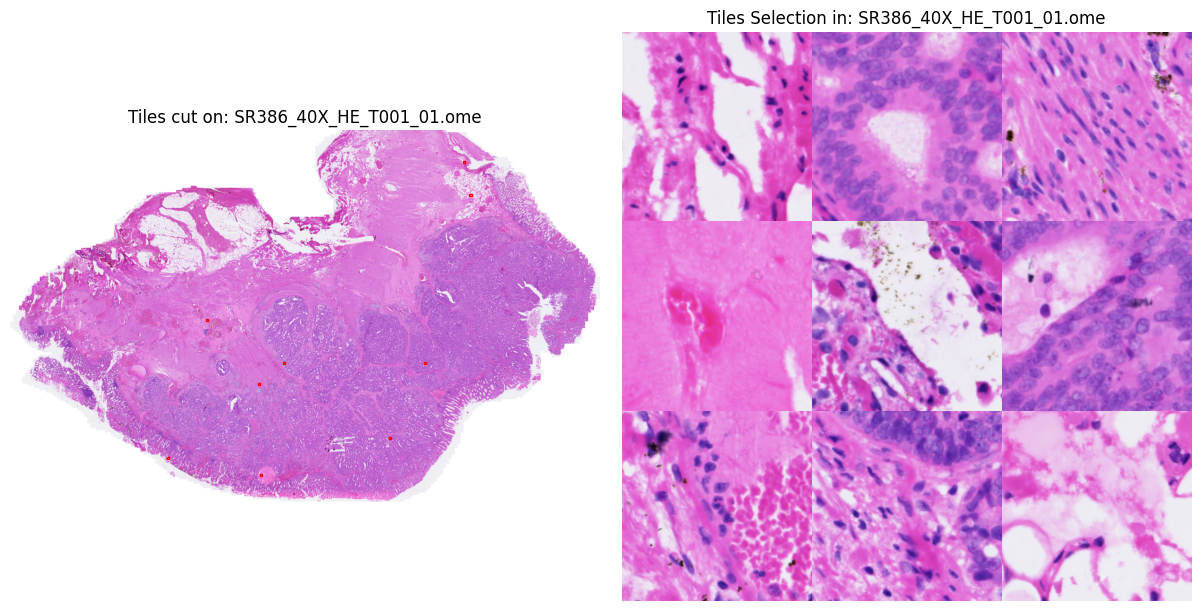

In [13]:
from histonaut.slide.draw import draw_cut, mosaic

fig, ax = plt.subplots(1, 2, figsize=(12, 6), layout="constrained")
draw_cut(
    slide,
    xywh=coords,
    analyse_level=patcher.level,
    level_to_view=4,
    ax=ax[0],
    show=False,
)
ax[0].set_title(f"Tiles cut on: {slide.name}")
mosaic(tiles, size=(PATCH_SIZE, PATCH_SIZE), ax=ax[1])
ax[1].set_title(f"Tiles Selection in: {slide.name}")
plt.show()